In [41]:
from pathlib import Path

import pandas as pd
import duckdb

In [42]:
DATA_BASE_PATH = Path("./data").resolve().absolute()

In [43]:
df = duckdb.query(
    f"""
    SELECT *
    FROM '{DATA_BASE_PATH / "fcd_gps_01_2022.parquet"}'
    LIMIT {10_000}
    """
).to_df()

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   recorded_timestamp  10000 non-null  datetime64[us]
 1   lon                 10000 non-null  float64       
 2   lat                 10000 non-null  float64       
 3   altitude            10000 non-null  float64       
 4   speed               10000 non-null  float64       
 5   orientation         10000 non-null  float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 468.9 KB


In [45]:
df.head()

,recorded_timestamp,lon,lat,altitude,speed,orientation
0,2022-01-01 00:00:00.063,22.912048,40.667297,5.2,0.0,339.0
1,2022-01-01 00:00:00.080,22.943557,40.688225,8.2,45.0,305.0
2,2022-01-01 00:00:00.197,22.925150,40.656532,6.1,0.0,38.0
3,2022-01-01 00:00:00.247,22.975777,40.525467,3.6,0.0,5.0
4,2022-01-01 00:00:00.287,22.921517,40.726602,25.8,0.0,318.0


In [46]:
df.describe()

,recorded_timestamp,lon,lat,altitude,speed,orientation
count,10000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,2022-01-01 00:09:14.572685,22.948332,40.620274,5.909130,17.91990,184.825000
min,2022-01-01 00:00:00.063000,22.813003,40.422263,-3.400000,0.00000,0.000000
25%,2022-01-01 00:04:41.881000,22.935373,40.602890,2.600000,0.00000,114.000000
50%,2022-01-01 00:09:18.393000,22.949205,40.630968,5.100000,0.00000,180.000000
75%,2022-01-01 00:13:51.997000,22.963755,40.649371,7.500000,36.00000,283.000000
max,2022-01-01 00:18:10.413000,23.081808,40.726672,39.400000,119.00000,360.000000
std,NaN,0.029516,0.046065,5.198387,23.66326,104.338309


<Axes: title={'center': 'Longitude and Latitude over Time'}, xlabel='recorded_timestamp'>

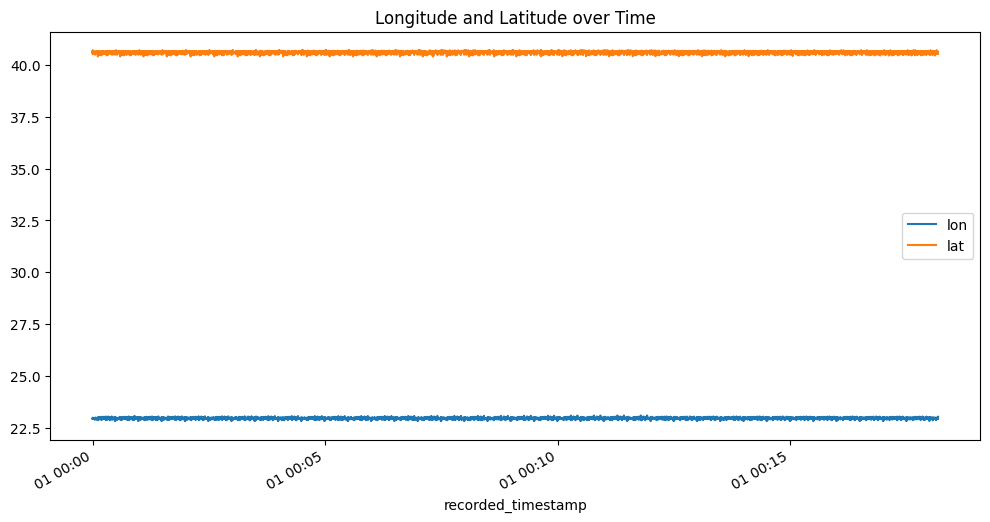

In [47]:
df.plot(
    x="recorded_timestamp",
    y=["lon", "lat"],
    figsize=(12, 6),
    title="Longitude and Latitude over Time",
)

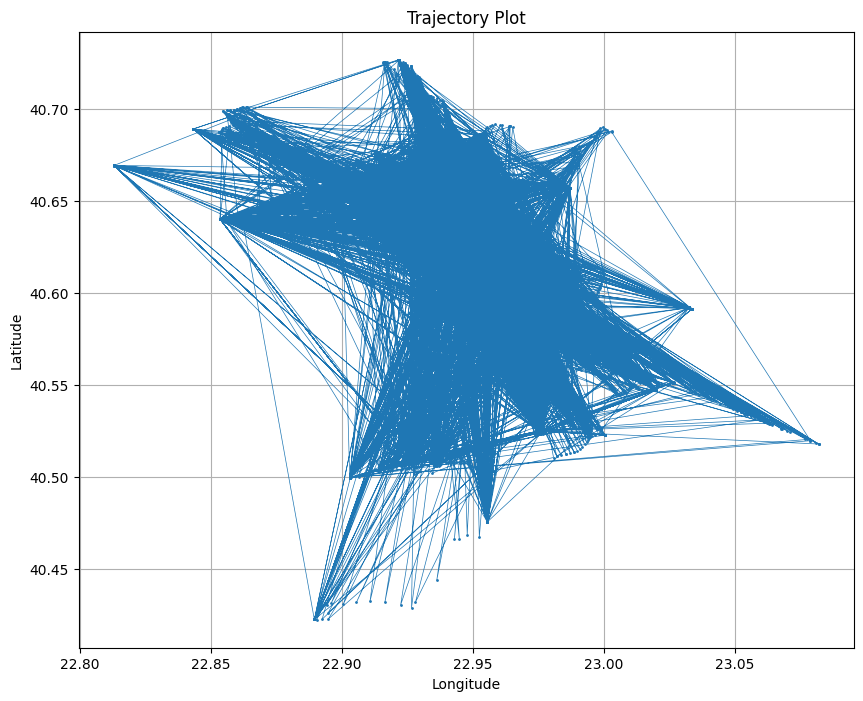

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.plot(df["lon"], df["lat"], marker="o", markersize=1, linestyle="-", linewidth=0.5)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Trajectory Plot")
plt.grid(True)
plt.show()